# VerdeScan -- Afforestation Survival Classification

> **Can a drone tell you which saplings are dead?**

The Odisha Forest Department plants ~5 crore saplings every year. Tracking which ones survived used to mean walking every field by hand -- slow, expensive, and covering barely 5% of patches.

VerdeScan replaces that with a ResNet18 classifier trained on real drone orthomosaic tiles. Given a 224x224 crop from a drone image taken a few months after planting, it answers one question:

| Class | Meaning |
|---|---|
| **alive** | Sapling is present and green |
| **dead** | Pit location but no surviving sapling |
| **no_sapling** | Bare ground / empty pit, nothing planted here |

This notebook covers:
1. Dataset exploration -- what the tiles look like and why they look that way
2. Training the ResNet18 classifier from scratch on the Kaggle dataset
3. Evaluating with confusion matrix, per-class F1, and misclassification analysis
4. Inference on new tiles using the pre-trained model
5. How this connects to the full GPS-aware ortho pipeline

**Dataset:** [`dealer09/verdescan-afforestation-tiles`](https://www.kaggle.com/datasets/dealer09/verdescan-afforestation-tiles) -- 15,000 tiles, 5,000 per class  
**Pre-trained model:** [`dealer09/verdescan-forest-model`](https://www.kaggle.com/models/dealer09/verdescan-forest-model)  
**GitHub:** [`Dealer-09/VerdeScan`](https://github.com/Dealer-09/VerdeScan)

## 1 . Setup

In [1]:
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import torchvision.transforms as transforms
warnings.filterwarnings("ignore")

# -- reproducibility ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory // 1024**2} MB")

# -- paths --------------------------------------------------------------------
CLASS_NAMES = ["alive", "dead", "no_sapling"]
COLORS      = {"alive": "#22c55e", "dead": "#dc2626", "no_sapling": "#f59e0b"}
OUTPUT_DIR  = Path("/kaggle/working")

DATASET_DIR = Path("/kaggle/input/datasets/dealer09/verdescan-afforestation-tiles/processed_dataset_v2")
MODEL_DIR   = Path("/kaggle/input/models/dealer09/verdescan-forest-model/pytorch/resnet18-afforestation-3class")

print(f"\nDataset root : {DATASET_DIR}")
for cls in CLASS_NAMES:
    n = len(list((DATASET_DIR / cls).glob("*.jpg")))
    print(f"  {cls:12s}: {n:,} tiles")

Device : cuda
GPU    : Tesla T4
VRAM   : 14912 MB

Dataset root : /kaggle/input/datasets/dealer09/verdescan-afforestation-tiles/processed_dataset_v2
  alive       : 5,000 tiles
  dead        : 5,000 tiles
  no_sapling  : 5,000 tiles


## 2 . Dataset Exploration

The dataset contains tiles extracted from DJI drone orthomosaics flown over **Benkmura VF** and **Debadihi VF** in Odisha. Four survey stages feed the three classes:

```
Pre-Pitting  -->  no_sapling   (bare ground before digging)
Post-Pitting -->  no_sapling   (dug pits, nothing planted yet)
Post-Planting-->  alive        (fresh saplings, monsoon growth)
Post-SW      -->  alive / dead (survival walk, months later)
```

Labelling is programmatic -- no manual annotation. Each tile passes an HSV colour threshold:
- **alive** -> green fraction > 25-28 %
- **dead** -> brown fraction > 28 %, green < 8 % (Post-SW stage only)
- **no_sapling** -> brown fraction > 30-35 % (pit stages)

In [2]:
# -- tile counts ---------------------------------------------------------------
counts = {}
for cls in CLASS_NAMES:
    cls_dir = DATASET_DIR / cls
    counts[cls] = len(list(cls_dir.glob('*.jpg')))

print('Tile counts:')
for cls, n in counts.items():
    bar = '#' * (n // 200)
    print(f'  {cls:12s} {n:6,d}  {bar}')
print(f'  {"TOTAL":12s} {sum(counts.values()):6,d}')

Tile counts:
  alive         5,000  #########################
  dead          5,000  #########################
  no_sapling    5,000  #########################
  TOTAL        15,000


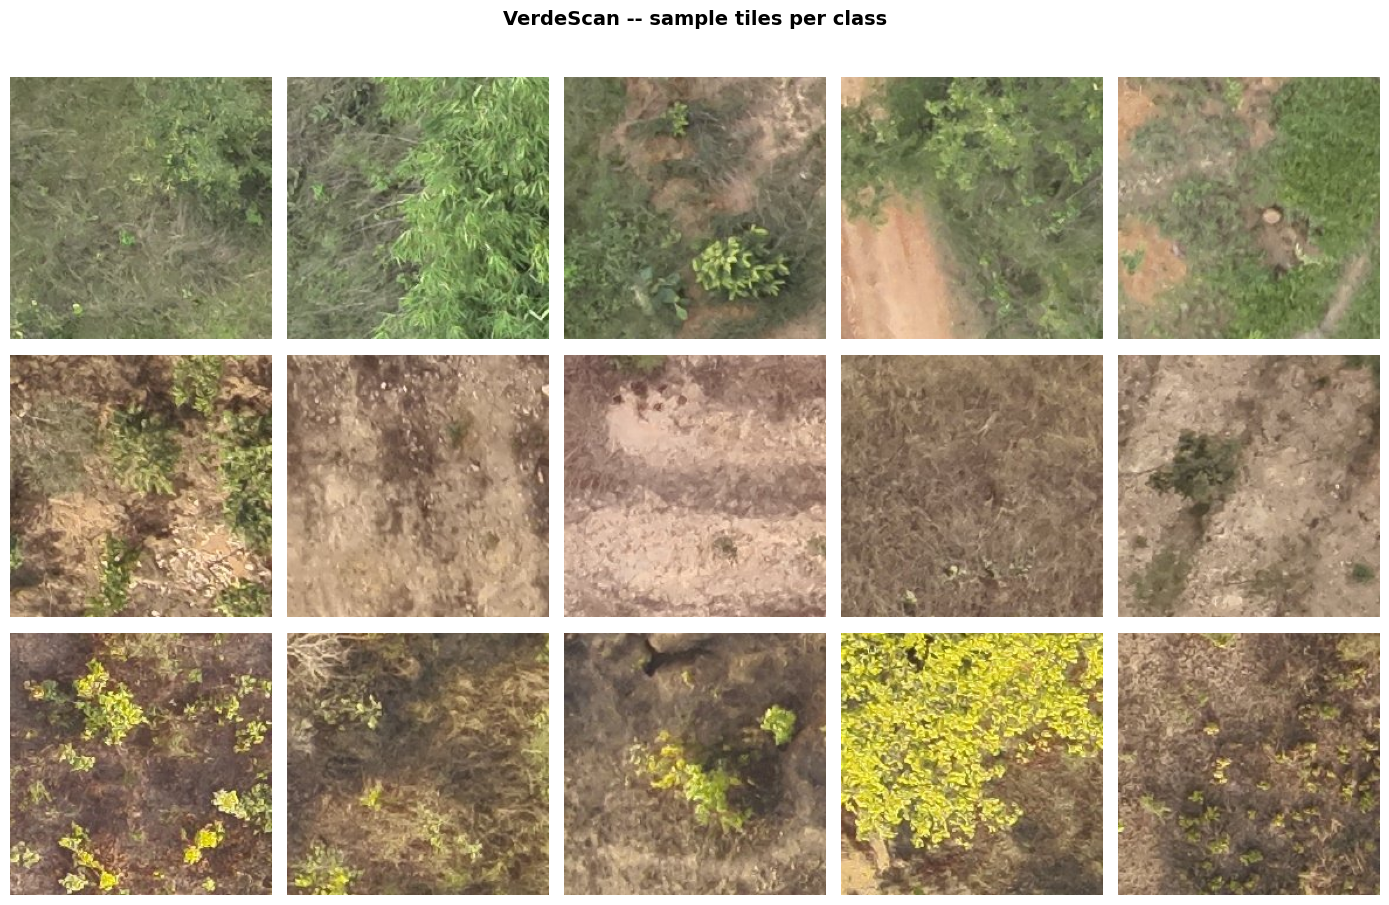

Saved -> sample_tiles.png


In [3]:
# -- visual sample -- up to 5 tiles per class --------------------------------
N_SHOW = 5
fig, axes = plt.subplots(3, N_SHOW, figsize=(14, 9))
fig.suptitle("VerdeScan -- sample tiles per class", fontsize=14, fontweight="bold", y=1.01)

rng = random.Random(SEED)

for row, cls in enumerate(CLASS_NAMES):
    cls_dir   = DATASET_DIR / cls
    all_tiles = list(cls_dir.glob("*.jpg"))
    k         = min(N_SHOW, len(all_tiles))
    samples   = rng.sample(all_tiles, k)
    for col in range(N_SHOW):
        ax = axes[row][col]
        if col < k:
            img = cv2.cvtColor(cv2.imread(str(samples[col])), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls, fontsize=12, fontweight="bold",
                          color=COLORS[cls], rotation=0, labelpad=60, va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_tiles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> sample_tiles.png")


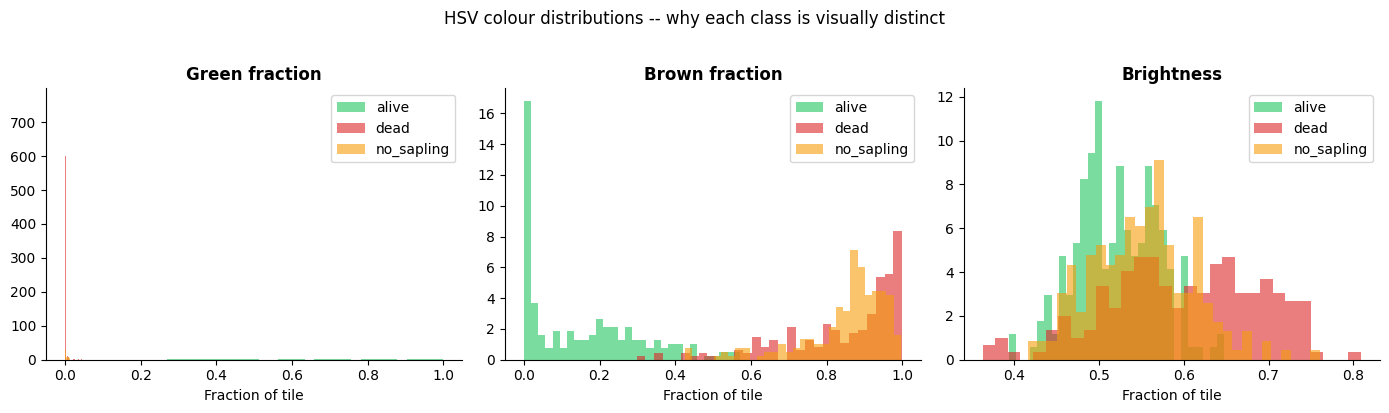

In [4]:
# -- HSV colour distribution per class ---------------------------------------
def hsv_stats(cls_dir: Path, n_sample: int = 200, seed: int = SEED):
    rng       = random.Random(seed)
    all_tiles = list(cls_dir.glob("*.jpg"))
    k         = min(n_sample, len(all_tiles))
    paths     = rng.sample(all_tiles, k)
    greens, browns, brights = [], [], []
    for p in paths:
        img = cv2.imread(str(p))
        if img is None:
            continue
        hsv   = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        total = 224 * 224
        greens.append(cv2.countNonZero(cv2.inRange(hsv, np.array([35,40,40]), np.array([85,255,255]))) / total)
        browns.append(cv2.countNonZero(cv2.inRange(hsv, np.array([5, 30,20]), np.array([25,255,200]))) / total)
        brights.append(float(np.mean(hsv[:,:,2])) / 255.0)
    return np.array(greens), np.array(browns), np.array(brights)

stats = {cls: hsv_stats(DATASET_DIR / cls) for cls in CLASS_NAMES}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric_idx, label in zip(axes, [0, 1, 2], ["Green fraction", "Brown fraction", "Brightness"]):
    for cls in CLASS_NAMES:
        ax.hist(stats[cls][metric_idx], bins=30, alpha=0.6, color=COLORS[cls], label=cls, density=True)
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Fraction of tile")
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("HSV colour distributions -- why each class is visually distinct", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hsv_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


## 3 . Data Pipeline

The dataset uses a **source-image-level train/val split** -- all tiles from the same drone flight stay in the same split. This prevents data leakage: a model trained on tile `(100, 200)` from a flight shouldn't also be evaluated on tile `(100, 224)` from the same image.

In [5]:
import re

def source_name(filename: str) -> str:
    """Strip tile coordinates to recover the source image name."""
    return re.sub(r'_\d+_\d+\.jpg$', '', filename)


class TileDataset(Dataset):
    def __init__(self, tile_list, transform=None):
        self.tiles     = tile_list
        self.transform = transform

    def __len__(self):
        return len(self.tiles)

    def __getitem__(self, idx):
        path, label = self.tiles[idx]
        img = cv2.imread(str(path))
        if img is None:
            return torch.zeros(3, 224, 224), label
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(img)
        return img, label


# -- transforms ----------------------------------------------------------------
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

TRAIN_TF = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.1, scale=(0.02, 0.08)),
])

VAL_TF = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


# -- source-image-level split -------------------------------------------------
VAL_FRAC = 0.20

by_source = defaultdict(list)  # source_name -> [(path, label)]
for label, cls in enumerate(CLASS_NAMES):
    for p in (DATASET_DIR / cls).glob('*.jpg'):
        by_source[source_name(p.name)].append((p, label))

sources_by_class = defaultdict(list)
for src, tiles in by_source.items():
    sources_by_class[tiles[0][1]].append(src)

train_tiles, val_tiles = [], []
rng = random.Random(SEED)
for cls_label, srcs in sources_by_class.items():
    rng.shuffle(srcs)
    n_val = max(1, int(len(srcs) * VAL_FRAC))
    for s in srcs[:n_val]:  val_tiles.extend(by_source[s])
    for s in srcs[n_val:]: train_tiles.extend(by_source[s])

train_ds = TileDataset(train_tiles, TRAIN_TF)
val_ds   = TileDataset(val_tiles,   VAL_TF)

# class counts per split
def split_counts(tiles):
    c = defaultdict(int)
    for _, l in tiles: c[CLASS_NAMES[l]] += 1
    return dict(c)

print(f'Train: {len(train_tiles):,} tiles  {split_counts(train_tiles)}')
print(f'Val  : {len(val_tiles):,} tiles  {split_counts(val_tiles)}')

Train: 12,000 tiles  {'alive': 4000, 'dead': 4000, 'no_sapling': 4000}
Val  : 3,000 tiles  {'alive': 1000, 'dead': 1000, 'no_sapling': 1000}


In [6]:
# -- DataLoaders ---------------------------------------------------------------
BATCH       = 128
NUM_WORKERS = 2  # Kaggle notebooks: keep low to avoid OOM

loader_kw = dict(
    num_workers      = NUM_WORKERS,
    pin_memory       = (DEVICE.type == 'cuda'),
    persistent_workers = (NUM_WORKERS > 0),
    prefetch_factor  = 2 if NUM_WORKERS > 0 else None,
)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, **loader_kw)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

Train batches : 94
Val   batches : 24


## 4 . Model

ResNet18 pretrained on ImageNet with the final fully-connected layer replaced:

```
ResNet18 backbone  ->  512-d feature vector
                   ->  Dropout(0.3)
                   ->  Linear(512 -> 3)
                   ->  softmax  [alive | dead | no_sapling]
```

The backbone stays unfrozen -- full fine-tuning converges faster than head-only training for a domain this different from ImageNet.

In [7]:
def build_model(num_classes: int, device) -> nn.Module:
    model = tv_models.resnet18(weights=None)  # no download
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(model.fc.in_features, num_classes),
    )
    return model.to(device)

model = build_model(len(CLASS_NAMES), DEVICE)

# Load your trained weights from MODEL_DIR
ckpt_path = Path("/kaggle/input/models/dealer09/verdescan-forest-model/pytorch/resnet18-afforestation-3class/1") / "forest_model.pth"
state = torch.load(ckpt_path, map_location=DEVICE)

# handle both raw state_dict and checkpoint dicts
if isinstance(state, dict) and "model_state_dict" in state:
    model.load_state_dict(state["model_state_dict"])
elif isinstance(state, dict) and "state_dict" in state:
    model.load_state_dict(state["state_dict"])
else:
    model.load_state_dict(state)

model.eval()
print(f"Loaded weights from : {ckpt_path}")
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params        : {total_params:,}")
print(f"Trainable params    : {trainable_params:,}")
print(f"Head                : {model.fc}")

Loaded weights from : /kaggle/input/models/dealer09/verdescan-forest-model/pytorch/resnet18-afforestation-3class/1/forest_model.pth
Total params        : 11,178,051
Trainable params    : 11,178,051
Head                : Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=3, bias=True)
)


## 5 . Training

- **Adam** lr=1e-4, weight_decay=1e-4  
- **ReduceLROnPlateau** -- halves LR if val loss stalls for 2 epochs  
- **AMP FP16** -- ~2x throughput on Kaggle T4/P100  
- **Early stopping** patience=5 on val loss  

The original training run stopped at **epoch 8** with val accuracy **99.9%**.

In [8]:
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for data, labels in loader:
            data, labels = data.to(device), labels.to(device)
            out = model(data)
            loss_sum += criterion(out, labels).item()
            all_preds.extend(torch.argmax(out, 1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    n  = len(CLASS_NAMES)
    cm = np.zeros((n, n), dtype=int)
    for p, l in zip(all_preds, all_labels): cm[l][p] += 1
    acc = np.diag(cm).sum() / cm.sum()

    metrics = {}
    for i, cls in enumerate(CLASS_NAMES):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        p  = tp / (tp + fp) if (tp + fp) else 0
        r  = tp / (tp + fn) if (tp + fn) else 0
        metrics[cls] = dict(precision=p, recall=r, f1=2*p*r/(p+r) if (p+r) else 0)

    return loss_sum / len(loader), acc, cm, metrics

In [9]:
EPOCHS   = 15
PATIENCE = 5
SAVE_PATH = OUTPUT_DIR / 'forest_model_trained.pth'

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

use_amp = (DEVICE.type == 'cuda')
scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

# Enable TF32 + cudnn benchmark for max throughput on Kaggle GPUs
if use_amp:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32       = True
    torch.backends.cudnn.benchmark        = True

history = dict(train_loss=[], val_loss=[], train_acc=[], val_acc=[])
best_val_loss = float('inf')
stale = 0

print(f'Training on {DEVICE} | AMP={use_amp} | batch={BATCH}\n')
print(f'{"Epoch":>6}  {"Train Loss":>11}  {"Train Acc":>10}  {"Val Loss":>9}  {"Val Acc":>8}  {"LR":>8}  {"Time":>6}')
print('-' * 75)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_loss, correct, total = 0.0, 0, 0

    for data, labels in train_loader:
        data, labels = data.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            out  = model(data)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        tr_loss  += loss.item()
        correct  += (torch.argmax(out, 1) == labels).sum().item()
        total    += labels.size(0)

    tr_loss /= len(train_loader)
    tr_acc   = correct / total

    v_loss, v_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(v_loss)
    lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(v_acc)

    flag = ''
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        stale = 0
        torch.save(model.state_dict(), SAVE_PATH)
        flag = ' < best'
    else:
        stale += 1

    print(f'{epoch:>6}  {tr_loss:>11.4f}  {tr_acc:>10.3f}  {v_loss:>9.4f}  {v_acc:>8.3f}  {lr:>8.2e}  {time.time()-t0:>5.1f}s{flag}')

    if stale >= PATIENCE:
        print(f'\nEarly stop -- no improvement for {PATIENCE} epochs.')
        break

print(f'\nBest model saved -> {SAVE_PATH}')

Training on cuda | AMP=True | batch=128

 Epoch   Train Loss   Train Acc   Val Loss   Val Acc        LR    Time
---------------------------------------------------------------------------
     1       0.0245       0.991     0.0071     0.999  1.00e-04  143.1s < best
     2       0.0301       0.990     0.0201     0.994  1.00e-04   77.3s
     3       0.0240       0.991     0.0051     0.998  1.00e-04   72.9s < best
     4       0.0252       0.991     0.0159     0.995  1.00e-04   73.1s
     5       0.0231       0.991     0.0025     1.000  1.00e-04   70.9s < best
     6       0.0228       0.991     0.0053     0.999  1.00e-04   71.1s
     7       0.0236       0.991     0.0069     0.998  1.00e-04   72.5s
     8       0.0194       0.993     0.0030     0.999  5.00e-05   75.2s
     9       0.0136       0.995     0.0024     0.999  5.00e-05   91.8s < best
    10       0.0133       0.995     0.0016     0.999  5.00e-05   75.4s < best
    11       0.0117       0.996     0.0018     0.999  5.00e-05   71

## 6 . Training Curves

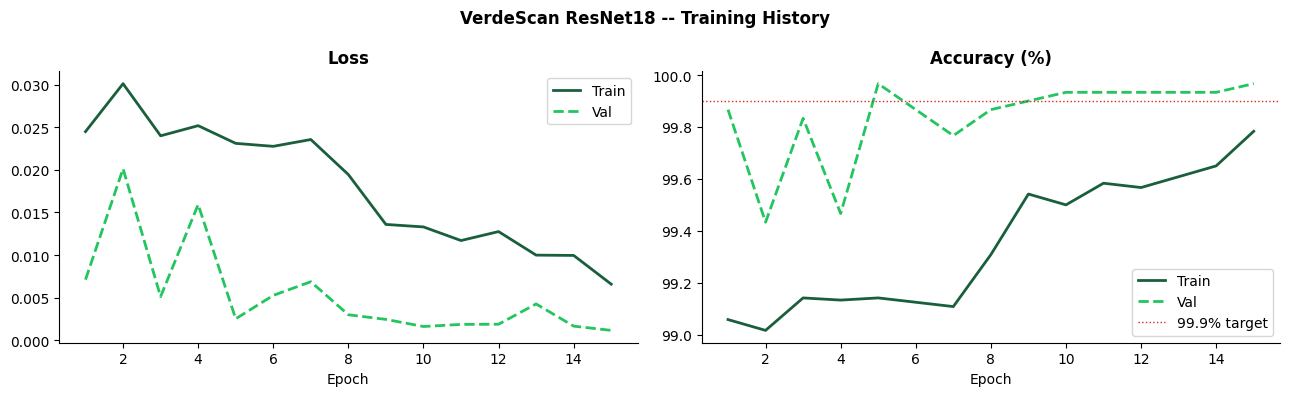

In [10]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs_ran, history['train_loss'], label='Train', color='#1a5f3c', linewidth=2)
ax1.plot(epochs_ran, history['val_loss'],   label='Val',   color='#22c55e', linewidth=2, linestyle='--')
ax1.set_title('Loss', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.legend(); ax1.spines[['top','right']].set_visible(False)

ax2.plot(epochs_ran, [a * 100 for a in history['train_acc']], label='Train', color='#1a5f3c', linewidth=2)
ax2.plot(epochs_ran, [a * 100 for a in history['val_acc']],   label='Val',   color='#22c55e', linewidth=2, linestyle='--')
ax2.axhline(99.9, color='#dc2626', linewidth=1, linestyle=':', label='99.9% target')
ax2.set_title('Accuracy (%)', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.legend(); ax2.spines[['top','right']].set_visible(False)

fig.suptitle('VerdeScan ResNet18 -- Training History', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 . Evaluation

In [11]:
# Load best checkpoint
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE, weights_only=True))
v_loss, v_acc, cm, per_class = evaluate(model, val_loader, criterion, DEVICE)

print(f'Val accuracy : {v_acc * 100:.2f}%')
print(f'Val loss     : {v_loss:.6f}\n')
print(f'{"Class":>12}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}')
print('-' * 45)
for cls, m in per_class.items():
    print(f'{cls:>12}  {m["precision"]:>10.3f}  {m["recall"]:>8.3f}  {m["f1"]:>8.3f}')

Val accuracy : 99.97%
Val loss     : 0.001146

       Class   Precision    Recall        F1
---------------------------------------------
       alive       1.000     1.000     1.000
        dead       1.000     0.999     0.999
  no_sapling       0.999     1.000     1.000


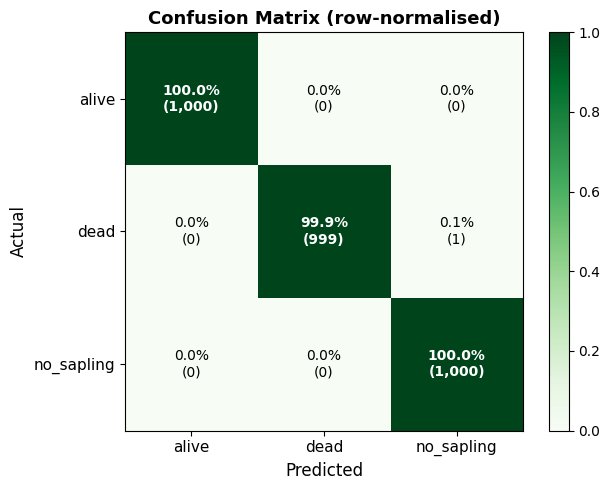

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

# Normalise by row (true label) for percentage view
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

im = ax.imshow(cm_norm, cmap='Greens', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_yticks(range(len(CLASS_NAMES))); ax.set_yticklabels(CLASS_NAMES, fontsize=11)
ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
ax.set_title('Confusion Matrix (row-normalised)', fontweight='bold', fontsize=13)

for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        pct = cm_norm[i, j]
        raw = cm[i, j]
        color = 'white' if pct > 0.6 else 'black'
        ax.text(j, i, f'{pct:.1%}\n({raw:,})', ha='center', va='center',
                fontsize=10, color=color, fontweight='bold' if i == j else 'normal')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

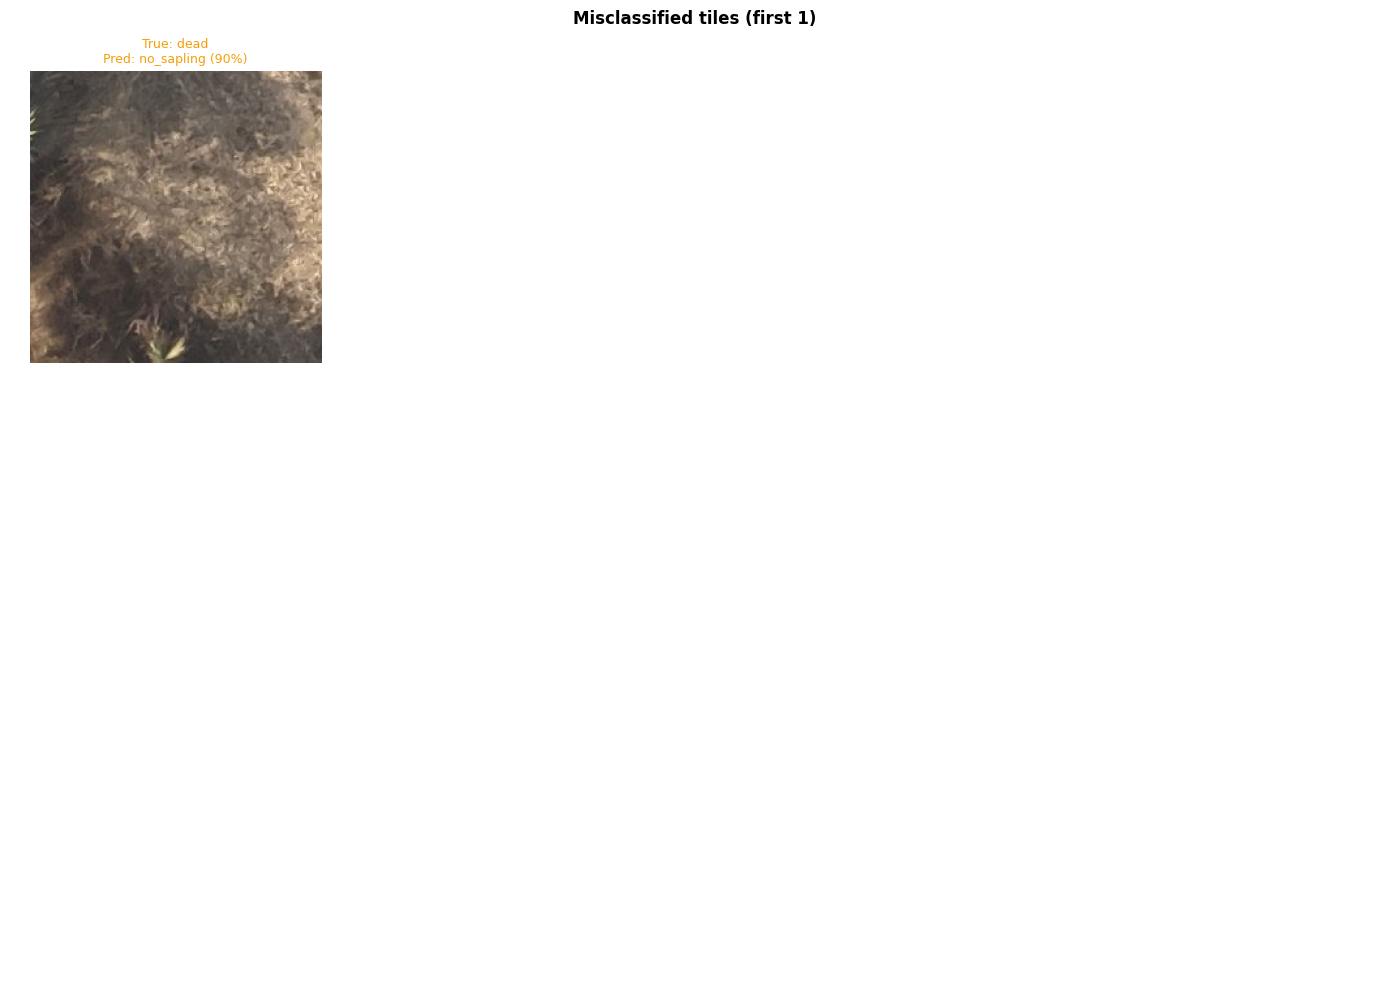

In [13]:
# -- show misclassified tiles --------------------------------------------------
model.eval()
wrong = []  # (img_tensor, true_label, pred_label, confidence)

with torch.no_grad():
    for data, labels in val_loader:
        out   = model(data.to(DEVICE))
        probs = torch.softmax(out, 1).cpu()
        preds = torch.argmax(probs, 1)
        mask  = preds != labels
        for img, tl, pl, pr in zip(data[mask], labels[mask], preds[mask], probs[mask]):
            wrong.append((img, tl.item(), pl.item(), pr[pl].item()))
        if len(wrong) >= 12:
            break

if wrong:
    n = min(len(wrong), 12)
    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    fig.suptitle(f'Misclassified tiles (first {n})', fontweight='bold')

    # Denormalise for display
    mean_t = torch.tensor(MEAN).view(3,1,1)
    std_t  = torch.tensor(STD ).view(3,1,1)

    for idx, ax in enumerate(axes.flat):
        if idx >= n:
            ax.axis('off'); continue
        img_t, true_l, pred_l, conf = wrong[idx]
        img_np = ((img_t * std_t + mean_t).permute(1,2,0).numpy() * 255).clip(0,255).astype(np.uint8)
        ax.imshow(img_np)
        ax.set_title(
            f'True: {CLASS_NAMES[true_l]}\nPred: {CLASS_NAMES[pred_l]} ({conf:.0%})',
            fontsize=9,
            color=COLORS[CLASS_NAMES[pred_l]]
        )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'misclassified.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No misclassified tiles found -- perfect val accuracy!')

## 8 . Inference with the Pre-trained Model

Skip training entirely and use the model already on Kaggle.

In [14]:
# -- load the Kaggle-hosted model ----------------------------------------------
import glob

pth_files = glob.glob(str(MODEL_DIR / '**' / '*.pth'), recursive=True)
if not pth_files:
    print('Pre-trained model not found -- using the model trained in this notebook instead.')
    pth_path = SAVE_PATH
else:
    pth_path = pth_files[0]
    print(f'Using pre-trained model: {pth_path}')

pretrained = build_model(3, DEVICE)
pretrained.load_state_dict(torch.load(pth_path, map_location=DEVICE, weights_only=True))
pretrained.eval()
print('Model loaded.')

Using pre-trained model: /kaggle/input/models/dealer09/verdescan-forest-model/pytorch/resnet18-afforestation-3class/1/forest_model.pth
Model loaded.


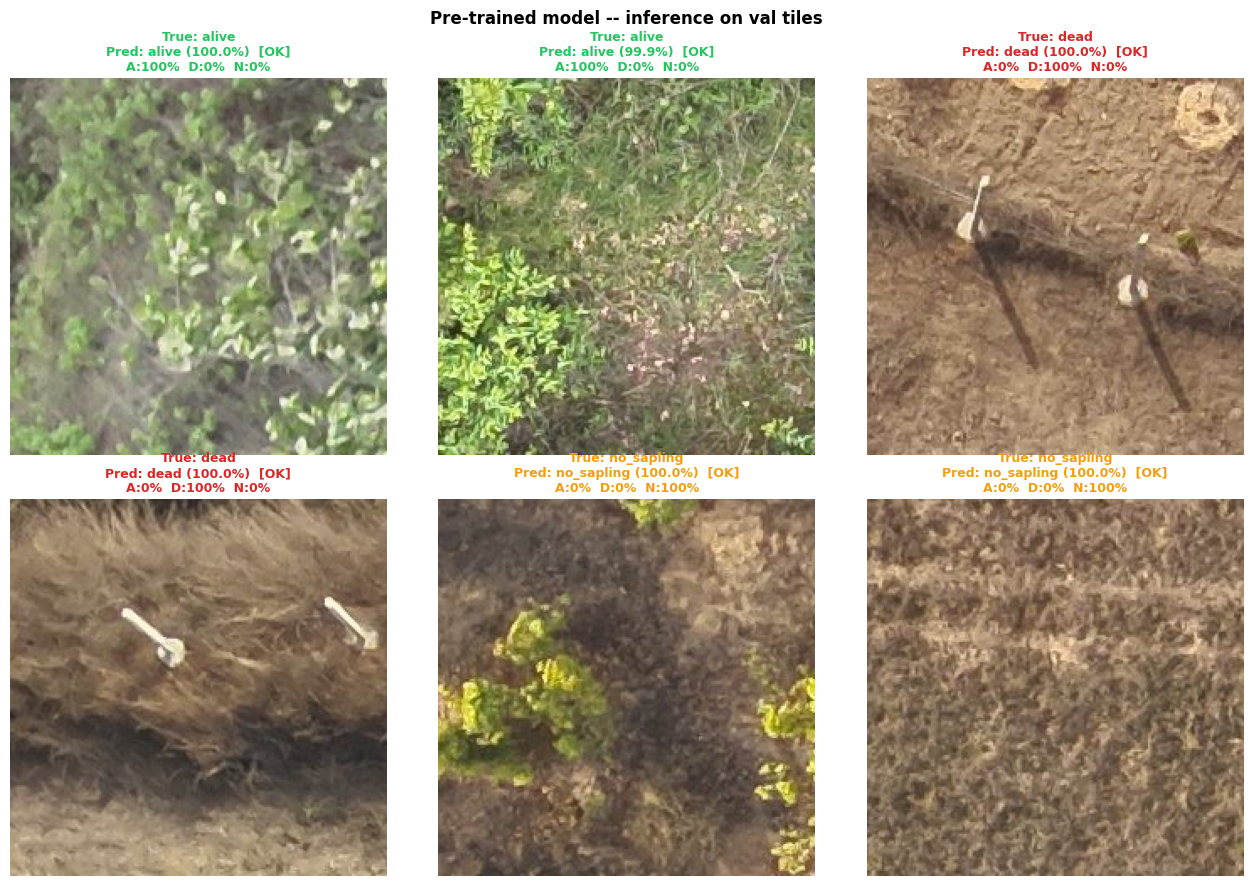

In [15]:
# -- classify a batch of random val tiles ------------------------------------
def classify_tile(model, img_path: Path, device) -> tuple:
    img    = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    tensor = VAL_TF(img).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()
    pred = int(np.argmax(probs))
    return CLASS_NAMES[pred], float(probs[pred]), probs

# Sample 2 tiles per class (safe)
samples = []
rng2 = random.Random(99)
for cls in CLASS_NAMES:
    all_tiles = list((DATASET_DIR / cls).glob("*.jpg"))
    k         = min(2, len(all_tiles))
    samples  += [(p, cls) for p in rng2.sample(all_tiles, k)]

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
fig.suptitle("Pre-trained model -- inference on val tiles", fontweight="bold")

for ax, (path, true_cls) in zip(axes.flat, samples):
    pred_cls, conf, probs = classify_tile(pretrained, path, DEVICE)
    img     = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
    correct = pred_cls == true_cls
    ax.imshow(img)
    ax.axis("off")
    prob_str = "  ".join(f"{CLASS_NAMES[i][0].upper()}:{probs[i]:.0%}" for i in range(3))
    ok_str   = "[OK]" if correct else "[X]"
    ax.set_title(
        f"True: {true_cls}\nPred: {pred_cls} ({conf:.1%})  {ok_str}\n{prob_str}",
        fontsize=9, color=COLORS[pred_cls],
        fontweight="bold" if correct else "normal",
    )

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "inference_demo.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 . From Tiles to GPS -- How the Full Pipeline Works

This classifier is one component of a larger system. The full VerdeScan pipeline is:

```
OP1 GeoTIFF orthomosaic (Post-Pitting)
    v
Hough circle detection -> all planting pit locations (pixel coords)
    v
GeoTIFF CRS -> WGS84 -> GPS lat/lon per pit  (~8,000 anchor points)
    v
OP3 GeoTIFF orthomosaic (Post-SW, months later)
    v
For each pit GPS -> project into OP3 pixel space -> crop 2m x 2m patch
    v
THIS MODEL  ->  alive / dead / no_sapling per pit
    v
GeoJSON output:  {lat, lon, status, confidence}  per pit
    v
Dashboard Field Map -- satellite view with green/red pins
Field teams navigate to exact GPS coordinates of casualties
```

### Results on real data

| Site | Planted | Pits detected | Alive | Dead | Survival |
|---|---|---|---|---|---|
| Benkmura VF | 8,000 | 2,921 | 881 | 2,040 | 30.2% |
| Debadihi VF | 10,000 | 1,768 | 10 | 1,758 | 0.6% |

The dead pit GPS coordinates are exported as GeoJSON -- field officers open the file in Google Earth and are navigated to each exact location to verify and replant.

### Full system
- **GitHub:** https://github.com/Dealer-09/VerdeScan
- **Dataset:** https://www.kaggle.com/datasets/dealer09/verdescan-afforestation-tiles
- **Model:** https://www.kaggle.com/models/dealer09/verdescan-forest-model

In [16]:
# -- final summary -------------------------------------------------------------
print('=' * 55)
print('  VerdeScan -- Training Summary')
print('=' * 55)
print(f'  Architecture : ResNet18 + Dropout(0.3) + Linear(512->3)')
print(f'  Dataset      : 15,000 tiles (5,000 per class)')
print(f'  Val accuracy : {v_acc * 100:.2f}%')
print(f'  Val loss     : {v_loss:.6f}')
print()
print(f'  Per-class F1:')
for cls, m in per_class.items():
    print(f'    {cls:>12}  {m["f1"]:.3f}')
print()
print(f'  Output model : {SAVE_PATH}')
print('=' * 55)

  VerdeScan -- Training Summary
  Architecture : ResNet18 + Dropout(0.3) + Linear(512->3)
  Dataset      : 15,000 tiles (5,000 per class)
  Val accuracy : 99.97%
  Val loss     : 0.001146

  Per-class F1:
           alive  1.000
            dead  0.999
      no_sapling  1.000

  Output model : /kaggle/working/forest_model_trained.pth
